In [1]:
"""
Electrospray Scaling Law Analyzer
---------------------------------

Uses:
- database.py module
- ElectrosprayDatabase class

Computes:
    d0, Q0, I0

Then:
- searches database for matching voltage
- computes mean current and flow rate
- plots:
        I/I0 vs Q/Q0
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
from pathlib import Path

# Add project root to Python path
sys.path.insert(0, str(r"C:\Users\HV\Desktop\bruno_work\main"))

from mapping.software.database import ElectrosprayDatabase


# ============================================================
# CONSTANTS
# ============================================================

EPSILON_0 = 8.854e-12  # vacuum permittivity


# ============================================================
# LIQUID PROPERTIES
# ============================================================

LIQUID = {
    "name": "Pure DMF",

    # SI units
    "surface_tension": 0.0364,      # N/m
    "density": 944.0,               # kg/m^3
    "conductivity": 1.5e-4,         # S/m
    "dielectric_constant": 36.7
}


# ============================================================
# USER SETTINGS
# ============================================================

DATABASE_FOLDER = "test"

TARGET_VOLTAGE = 5400       # volts
VOLTAGE_TOLERANCE = 100     # volts




In [2]:
# ============================================================
# SCALING LAWS
# ============================================================

def characteristic_diameter(sigma, rho, k):
    return ((sigma * EPSILON_0**2) / (rho * k**2))**(1/3)


def characteristic_flow_rate(sigma, rho, k):
    return (sigma * EPSILON_0) / (rho * k)


def characteristic_current(sigma, rho):
    return sigma * np.sqrt(EPSILON_0 / rho)


In [3]:
# ============================================================
# DATABASE SEARCH
# ============================================================

def get_matching_measurements():

    df = pd.read_csv("db.csv")

    #
    # Filter by:
    #   solution name
    #   target voltage
    #

    mask = (
        (df["image_classification"] == "cone_jet") &
        (
            np.abs(df["actual_voltage"] - TARGET_VOLTAGE)
            <= VOLTAGE_TOLERANCE
        )
    )

    return df[mask].copy()




In [4]:
# ============================================================
# MAIN
# ============================================================

    # --------------------------------------------------------
    # Load database
    # --------------------------------------------------------


# --------------------------------------------------------
# Compute characteristic scales
# --------------------------------------------------------

sigma = LIQUID["surface_tension"]
rho = LIQUID["density"]
k = LIQUID["conductivity"]

d0 = characteristic_diameter(sigma, rho, k)
Q0 = characteristic_flow_rate(sigma, rho, k)
I0 = characteristic_current(sigma, rho)

print("\n===================================")
print("Characteristic Scales")
print("===================================")

print(f"d0 = {d0:.3e} m")
print(f"Q0 = {Q0:.3e} m^3/s")
print(f"I0 = {I0:.3e} A")

# --------------------------------------------------------
# Get matching measurements
# --------------------------------------------------------
df= get_matching_measurements()




Characteristic Scales
d0 = 5.122e-07 m
Q0 = 2.276e-12 m^3/s
I0 = 3.525e-09 A


In [5]:
df

,id,timestamp,solution_name,hv_position,target_voltage,actual_voltage,actual_current_ps,flow_rate,mean_na,deviation_na,...,band_power_low,band_power_mid,band_power_high,band_power_v_high,rf_spray_mode,xgb_spray_mode,image_classification,manual_classification,video_file,raw_data_file
105,106,"2026-04-14T11:48:09,668",experiment,1,5400,5400.95,1.26898e-07,4,87.385117,15.657814,...,14.277482,15.169428,64.162365,35.326342,cone_jet (44%),multi_jet (45%),cone_jet,NaN,NaN,experiment_1_sample_12.npy
136,137,"2026-04-14T11:51:03,734",experiment,1,5400,5400.97,2.83382e-07,5,90.199799,16.000547,...,18.169828,16.318708,68.238253,34.854373,cone_jet (47%),cone_jet (51%),cone_jet,NaN,NaN,experiment_1_sample_43.npy
167,168,"2026-04-14T11:53:57,344",experiment,1,5400,5400.97,2.46726e-07,6,112.766479,16.072651,...,22.133815,15.265716,67.241374,35.643900,cone_jet (45%),cone_jet (88%),cone_jet,NaN,NaN,experiment_1_sample_74.npy
756,757,"2026-04-14T13:38:23,420",experiment,2,5400,5400.83,3.38016e-07,8,86.669899,15.246272,...,11.483045,14.903955,56.660643,31.673139,cone_jet (41%),cone_jet (66%),cone_jet,NaN,NaN,experiment_2_sample_43.npy
787,788,"2026-04-14T13:41:16,996",experiment,2,5400,5400.86,3.00575e-07,9,55.883091,15.133541,...,12.251106,11.479819,55.251469,31.999904,cone_jet (45%),cone_jet (40%),cone_jet,NaN,NaN,experiment_2_sample_74.npy
911,912,"2026-04-14T14:11:15,366",experiment,4,5400,5400.83,2.91411e-07,13,79.197723,15.519278,...,12.017719,13.479833,65.723706,33.002609,cone_jet (48%),cone_jet (46%),cone_jet,NaN,NaN,experiment_4_sample_12.npy
973,974,"2026-04-14T14:17:02,132",experiment,4,5400,5400.82,3.15586e-07,18,64.636292,15.288897,...,8.151239,12.415750,62.919052,32.697595,intermitent (42%),multi_jet (84%),cone_jet,NaN,NaN,experiment_4_sample_74.npy
1004,1005,"2026-04-14T14:24:04,835",experiment,5,5400,5400.80,2.70029e-07,20,86.049080,14.897923,...,9.026186,12.258508,53.431418,31.144158,intermitent (37%),multi_jet (43%),cone_jet,NaN,NaN,experiment_5_sample_12.npy



Loaded 8 matching measurements

Experimental Means
Mean Flow Rate = 1.729e-10 m^3/s
Mean Current   = 8.285e-08 A


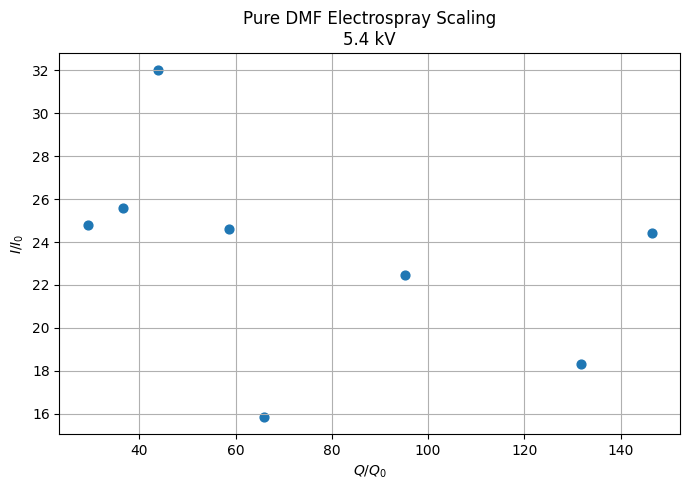

In [6]:
print(f"\nLoaded {len(df)} matching measurements")

    # --------------------------------------------------------
    # Convert units
    # --------------------------------------------------------

    #
    # flow_rate assumed:
    #   uL/min
    #
    # convert to m^3/s
    #

flow_rate_m3s = (
    df["flow_rate"].values
    * 1e-9
    / 60.0
)

#
# mean_na assumed:
#   nA
#
# convert to A
#
current_A = (
    df["mean_na"].values
    * 1e-9
)

    # --------------------------------------------------------
    # Dimensionless quantities
    # --------------------------------------------------------

Q_star = flow_rate_m3s / Q0
I_star = current_A / I0

    # --------------------------------------------------------
    # Statistics
    # --------------------------------------------------------

mean_flow = np.mean(flow_rate_m3s)
mean_current = np.mean(current_A)

print("\n===================================")
print("Experimental Means")
print("===================================")
print(f"Mean Flow Rate = {mean_flow:.3e} m^3/s")
print(f"Mean Current   = {mean_current:.3e} A")
# --------------------------------------------------------
    # Plot scaling law
    # --------------------------------------------------------

plt.figure(figsize=(7, 5))
plt.scatter(
    Q_star,
    I_star,
    s=40
)

plt.xlabel(r"$Q/Q_0$")
plt.ylabel(r"$I/I_0$")
plt.title(
    f"{LIQUID['name']} Electrospray Scaling\n"
    f"{TARGET_VOLTAGE/1000:.1f} kV"
)
plt.grid(True, which="both")
plt.tight_layout()
plt.show()

